<a href="https://colab.research.google.com/github/jonhnson248/knn-classificador-iris/blob/main/classificador_knn_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

from sklearn.datasets import load_iris

dados_iris = load_iris()

tabela = pd.DataFrame(data = dados_iris.data, columns = dados_iris.feature_names)

tabela['especie'] = dados_iris.target

tabela.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
from sklearn.model_selection import train_test_split

X = tabela.drop('especie', axis = 1)
y = tabela['especie']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"Flores para estudar (Treino): {len(X_treino)}")
print(f"Flores para a prova (Teste): {len(X_teste)}")

Flores para estudar (Treino): 120
Flores para a prova (Teste): 30


In [4]:
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier(n_neighbors=3)
modelo_knn.fit(X_treino, y_treino)
chutes_do_modelo = modelo_knn.predict(X_teste)

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix

nota_acuracia = accuracy_score(y_teste, chutes_do_modelo)
print(f"Acurácia do modelo: {nota_acuracia * 100}%")

Acurácia do modelo: 100.0%


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

matriz_confusao = confusion_matrix(y_teste, chutes_do_modelo)
print("Matriz de confusão:")
print(matriz_confusao)
print("-" * 40)

relatorio = classification_report(y_teste, chutes_do_modelo, target_names = dados_iris.target_names)
print("Relatorio de Classificação")
print(relatorio)

Matriz de confusão:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
----------------------------------------
Relatorio de Classificação
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [7]:
valores_acuracia = []
valores_k = range(1, 21)

for k in valores_k:
  modelo_knn_k = KNeighborsClassifier(n_neighbors = k)
  modelo_knn_k.fit(X_treino, y_treino)
  chutes_k = modelo_knn_k.predict(X_teste)
  nota_k = accuracy_score(y_teste, chutes_k)
  valores_acuracia.append(nota_k)
print(valores_acuracia)


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9666666666666667, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


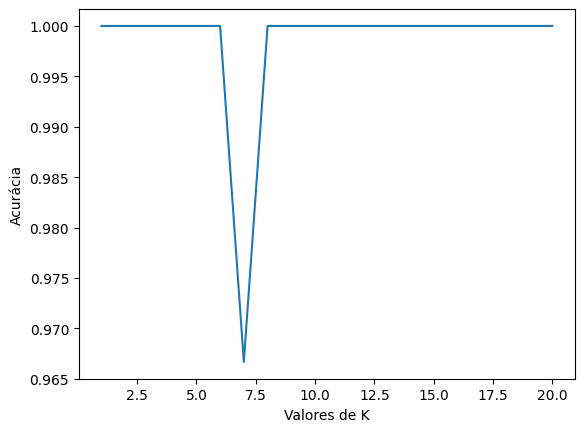

In [8]:
import matplotlib.pyplot as plt

plt.plot(valores_k, valores_acuracia)
plt.xlabel('Valores de K')
plt.ylabel('Acurácia')

plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV

grade_parametros = {'n_neighbors': range(1, 21)}
robo_base = KNeighborsClassifier()

maquina_grid = GridSearchCV(robo_base, grade_parametros, cv = 30)
maquina_grid.fit(X_treino, y_treino)

k_vencedor = maquina_grid.best_params_
print(k_vencedor)

{'n_neighbors': 14}


In [10]:
from sklearn.model_selection import cross_val_score

melhor_k = k_vencedor['n_neighbors']
robo_campeao = KNeighborsClassifier(n_neighbors = melhor_k)
notas_30_provas = cross_val_score(robo_campeao, X, y, cv = 30)

print("As 30 notas foram extraídas com sucesso!")

As 30 notas foram extraídas com sucesso!


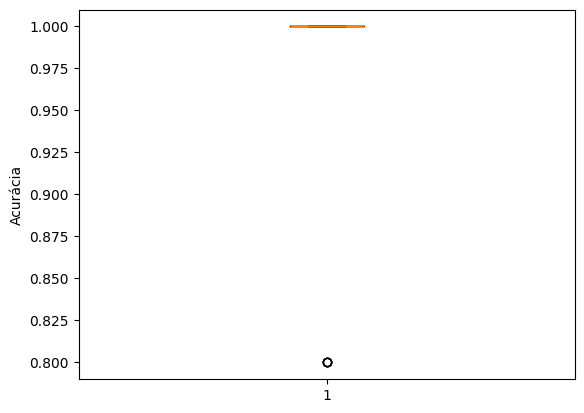

In [11]:
plt.boxplot(notas_30_provas)
plt.ylabel('Acurácia')

plt.show()